# Multi-Layer Perceptron (MLP) on MNIST using TensorFlow/Keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    TensorBoard
)

## Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (60000, 28, 28)
Test Shape : (10000, 28, 28)


## Visualize Digits

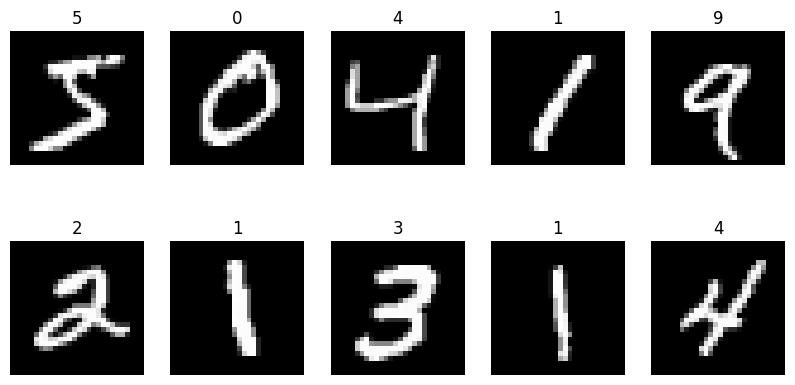

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

## Data Preprocessing

In [4]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


## Build MLP Architecture

In [5]:
model = Sequential([
    
    Dense(512, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

/Users/ayeshafaiz/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Training Callbacks

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_mnist_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

tensorboard = TensorBoard(
    log_dir='logs'
)

## Model Training

In [8]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    callbacks=[
        early_stop,
        checkpoint,
        tensorboard
    ],
    verbose=1
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8951 - loss: 0.3485 - val_accuracy: 0.9579 - val_loss: 0.1355
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9500 - loss: 0.1653 - val_accuracy: 0.9678 - val_loss: 0.1060
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9628 - loss: 0.1219 - val_accuracy: 0.9712 - val_loss: 0.0977
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9689 - loss: 0.1020 - val_accuracy: 0.9747 - val_loss: 0.0843
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9726 - loss: 0.0883 - val_accuracy: 0.9747 - val_loss: 0.0860
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9757 - loss: 0.0795 - val_accuracy: 0.9747 - val_loss: 0.0843
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9774 - loss: 0.0725 - val_accuracy: 0.9779 - val_loss: 0.0795
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9796 - loss: 0.0628 - val_accuracy: 0.

## Training History

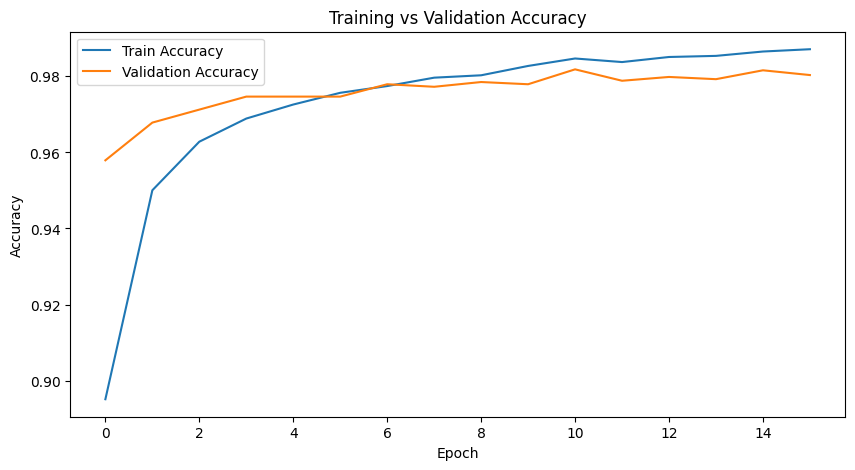

In [9]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

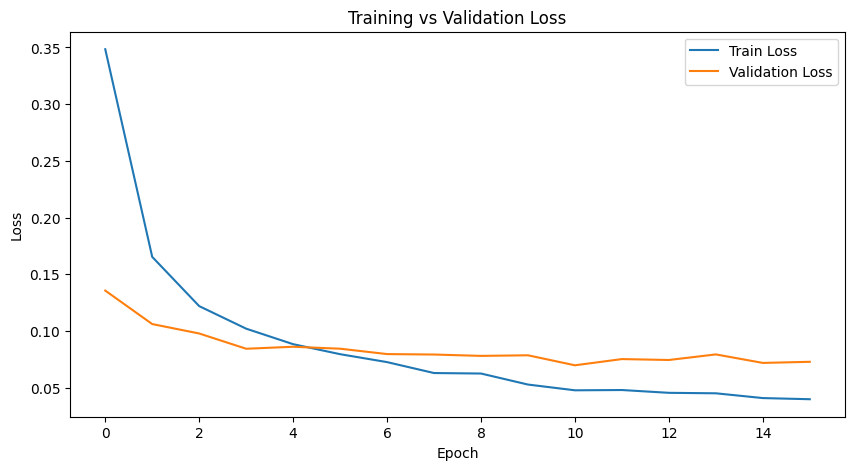

In [10]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

## Model Evaluation

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss,4))
print("Test Accuracy:", round(test_accuracy*100,2), "%")

Test Loss: 0.0622
Test Accuracy: 98.1 %


## Predictions

In [12]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(predicted_classes[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step
[7 2 1 0 4 1 4 9 6 9]
[7 2 1 0 4 1 4 9 5 9]


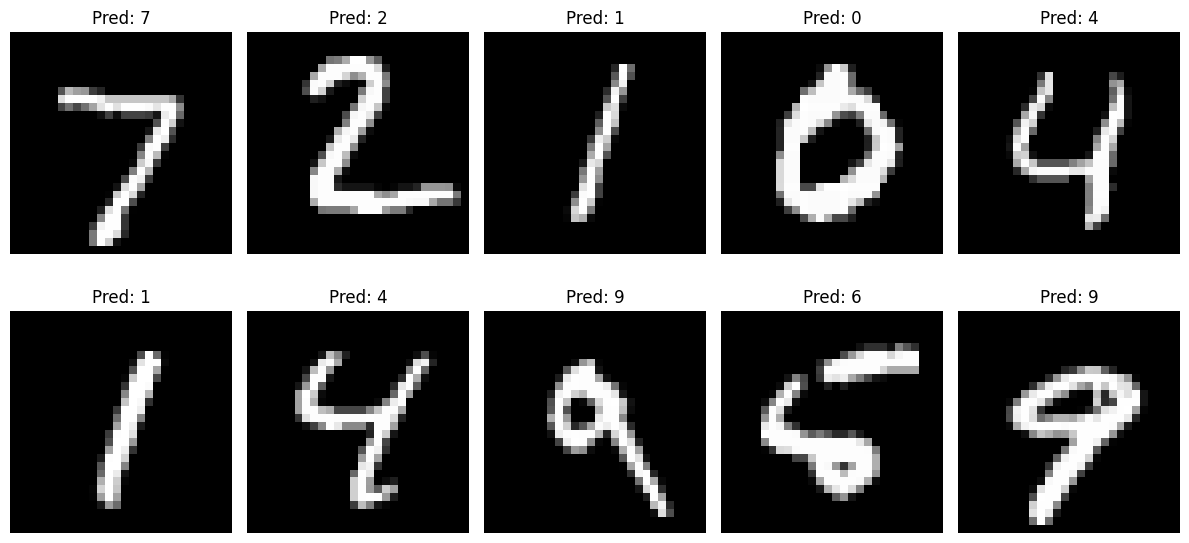

In [13]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Pred: {predicted_classes[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

## Save Model

In [14]:
model.save("mnist_mlp_final.keras")

print("Model Saved Successfully")

Model Saved Successfully


# Results and Conclusion

## Model Performance

The Multi-Layer Perceptron (MLP) was successfully trained on the MNIST handwritten digit dataset using TensorFlow/Keras.

### Key Components Implemented
- Dense (Fully Connected) Layers
- Batch Normalization
- Dropout Regularization
- Early Stopping
- Model Checkpointing
- TensorBoard Logging

### Final Results
- Training Accuracy: 98.4%
- Validation Accuracy: 98.18% (Epoch 11)
- Test Accuracy: 98.10%
- Test Loss: 0.0622

### Observations
- Batch Normalization improved training stability and convergence speed.
- Dropout reduced overfitting and improved generalization.
- EarlyStopping prevented unnecessary training after validation performance stopped improving.
- The model achieved the target accuracy of more than 97% on the MNIST test dataset.
- TensorBoard was used to monitor training and validation metrics throughout the training process.

## Conclusion

This project demonstrated how to build and train a deep neural network using TensorFlow/Keras for image classification. By combining Dense layers with Batch Normalization and Dropout, the model achieved high accuracy while maintaining good generalization performance. The use of callbacks such as EarlyStopping and ModelCheckpoint improved the training workflow and ensured that the best-performing model was saved for future use.